# Lecture 04 — Battery charging and work decisions

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Reinforcement learning (tabular Q-learning) · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Train a Q-learning policy that balances charging cost against work reward.

## Practical problem
An automated device has battery levels 0 to 5 and can choose Charge or Work. The data encode transition rules.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** Rewards are illustrative and omit battery wear, charger physics, safety and uncertainty.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 12 rows × 5 columns


,battery_level,action,action_name,next_battery_level,reward
0,0,0,Charge,2,-1.7
1,0,1,Work,0,-7.0
2,1,0,Charge,3,-1.7
3,1,1,Work,0,3.2
4,2,0,Charge,4,-1.7


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['battery_level', 'action', 'action_name', 'next_battery_level', 'reward']
Missing values per column:
battery_level         0
action                0
action_name           0
next_battery_level    0
reward                0


## 2. Define states, actions, rewards and transitions
An RL agent learns by taking actions and receiving rewards. Here `dataset.csv` describes a **simulated environment**, not a labelled set of optimal actions. This is a tabular Q-learning demonstration.

Reward table:


action_name,Charge,Work
battery_level,,
0,-1.70,-7.0
1,-1.70,3.2
2,-1.70,3.2
3,-1.70,3.2
4,-1.95,3.2
5,-1.95,3.2


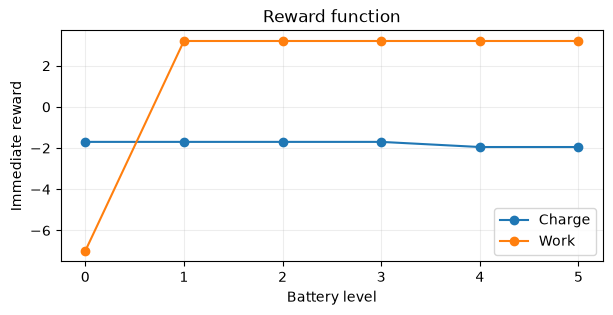

In [3]:
actions=['Charge','Work']
transitions={(int(r.battery_level),int(r.action)):(int(r.next_battery_level),float(r.reward)) for r in df.itertuples()}
print('Reward table:');display(df.pivot(index='battery_level',columns='action_name',values='reward'))
plt.figure(figsize=(7,3));plt.plot(df[df.action==0].battery_level,df[df.action==0].reward,'o-',label='Charge')
plt.plot(df[df.action==1].battery_level,df[df.action==1].reward,'o-',label='Work')
plt.xlabel('Battery level');plt.ylabel('Immediate reward');plt.title('Reward function');plt.legend();plt.show()

## 3. Train by exploring the environment
Q-learning updates an action value toward `reward + γ × best future Q`. Exploration (ε-greedy) helps an agent learn rather than repeating an initially arbitrary action.

In [4]:
rng=np.random.default_rng(42);Q=np.zeros((6,2));alpha=.2;gamma=.92;eps=.2
returns=[]
for episode in range(1800):
 state=int(rng.integers(0,6));total=0
 for t in range(25):
  a=int(rng.integers(0,2)) if rng.random()<eps else int(np.argmax(Q[state]))
  nxt,r=transitions[(state,a)];Q[state,a]+=alpha*(r+gamma*np.max(Q[nxt])-Q[state,a]);state=nxt;total+=r
 returns.append(total)
print('Learned action at each charge level:',[actions[np.argmax(Q[i])] for i in range(6)])

Learned action at each charge level: ['Charge', 'Work', 'Work', 'Work', 'Work', 'Work']


## 4. Evaluate the learned policy
RL evaluation focuses on **episode return, task success rate or operational reward**, not a confusion matrix. There are no supervised target classes in these examples.

In [5]:
def policy_rollout(start=1,steps=12):
 state=start;route=[state];rewards=[];acts=[]
 for t in range(steps):
  a=int(np.argmax(Q[state]));nxt,r=transitions[(state,a)]
  acts.append(actions[a]);route.append(nxt);rewards.append(r);state=nxt
 return route,acts,rewards
path,acts,rewards=policy_rollout()
print('Actions:',acts)
print('Battery trace:',path)
print('Total reward:',round(sum(rewards),1))

Actions: ['Work', 'Charge', 'Work', 'Work', 'Charge', 'Work', 'Work', 'Charge', 'Work', 'Work', 'Charge', 'Work']
Battery trace: [1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1]
Total reward: 18.8


## 5. Visualise what was learned

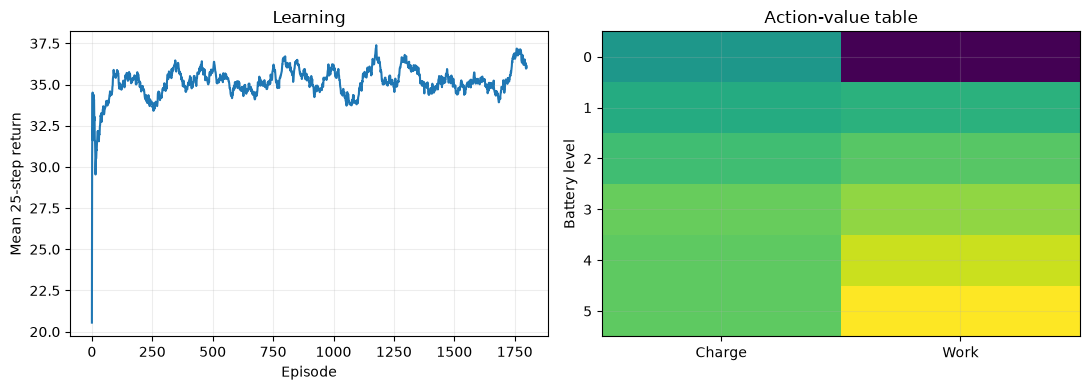

In [6]:
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(pd.Series(returns).rolling(75,min_periods=1).mean());ax[0].set(xlabel='Episode',ylabel='Mean 25-step return',title='Learning')
ax[1].imshow(Q,aspect='auto',cmap='viridis');ax[1].set(xticks=[0,1],xticklabels=actions,yticks=range(6),ylabel='Battery level',title='Action-value table')
plt.tight_layout();plt.show()

## 6. Apply the learned policy to new starting conditions

In [7]:
for level in [0,1,3,5]:
 route,actions_used,rews=policy_rollout(level,8)
 print(f'Initial battery {level}: first action={actions_used[0]}, reward={sum(rews):.1f}, battery trace={route}')

Initial battery 0: first action=Charge, reward=10.9, battery trace=[0, 2, 1, 0, 2, 1, 0, 2, 1]
Initial battery 1: first action=Work, reward=10.9, battery trace=[1, 0, 2, 1, 0, 2, 1, 0, 2]
Initial battery 3: first action=Work, reward=15.8, battery trace=[3, 2, 1, 0, 2, 1, 0, 2, 1]
Initial battery 5: first action=Work, reward=20.7, battery trace=[5, 4, 3, 2, 1, 0, 2, 1, 0]


## Student investigation and discussion
1. Why might an agent charge when the immediate reward is negative?
2. What changes if charging costs double?
3. Why is episode return more relevant than classification accuracy?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.